Send all your code to : amritansh@learnbay.co

### Problem Statement # 1

Problem Statement: Bike Sharing Demand Prediction
Background

You are a data scientist working for a bike-sharing company in Washington D.C. The company operates a fleet of bicycles that users can rent from various stations throughout the city. Accurate demand prediction is crucial for:

    1. Optimal bike distribution across stations
    2. Maintenance scheduling during low-demand periods
    3. Operational cost reduction by avoiding overstocking/understocking
    4. Better user experience by ensuring bike availability

Your task is to build regression models that predict hourly bike rental demand based on environmental and seasonal factors.
Dataset Description

The dataset contains 17,379 hourly records spanning two years with the following features:
Features (Independent Variables):

    1. temp: Normalized temperature in Celsius (0 to 1 scale)
    2. atemp: Normalized "feels-like" temperature in Celsius
    3. hum: Normalized humidity (0 to 1 scale)
    4. windspeed: Normalized wind speed
    5. season: Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)
    6. weathersit: Weather situation (1: Clear, 2: Mist, 3: Light Rain/Snow, 4: Heavy Rain)
    7. hr: Hour of the day (0 to 23)
    8. holiday: Whether the day is a holiday (0: No, 1: Yes)
    9. weekday: Day of the week (0: Sunday to 6: Saturday)
    10. workingday: Whether it's a working day (0: No, 1: Yes)

Target Variable:

    cnt: Total count of bike rentals (casual + registered users)

Your Tasks
Part 1: Data Exploration (20%)

    Load the dataset and perform basic exploratory data analysis:
        * Check for missing values and outliers
        * Generate summary statistics
        * Visualize the distribution of the target variable (cnt)
    Create visualizations to understand relationships:
        * How does temperature affect bike rentals?
        * How does hour of the day impact demand?
        * Which weather conditions see the most/least rentals?
        * Are there patterns between seasons and demand?
    Answer these questions:
        * Do you observe any non-linear relationships between features and bike rentals?
        * Which features seem most correlated with bike demand?

Part 2: Feature Selection & Preprocessing (15%)

    Select the most relevant numerical features for your model (you may choose a subset of available features)
    Split your data into training (80%) and testing (20%) sets
    (Optional) Apply feature scaling if needed using StandardScaler

Note: You should work primarily with numerical features. Categorical features like season, weathersit can be used as-is since they're already encoded numerically.
Part 3: Model Development (40%)

Build and compare the following regression models:
Model 1: Simple Linear Regression

    Use a single feature (e.g., temperature) to predict bike rentals
    Evaluate performance on test data

Model 2: Multiple Linear Regression

    Use multiple features to predict bike rentals
    Compare performance with Model 1

Model 3: Polynomial Regression (Degree 2)

    Apply polynomial features of degree 2
    Train and evaluate the model
    Compare with linear regression

Model 4: Polynomial Regression (Degree 3)

    Apply polynomial features of degree 3
    Train and evaluate the model
    Compare with degree 2 polynomial

For each model, calculate:

    RMSE (Root Mean Squared Error)
    MAE (Mean Absolute Error)
    R² Score (Coefficient of Determination)

Part 4: Model Comparison & Analysis (25%)

    Create a comparison table showing all models' performance metrics
    Visualize predictions:
        Plot actual vs. predicted values for your best model
        Create residual plots to check for patterns
    Answer these questions:
        Which model performs best? Why do you think so?
        Does polynomial regression improve performance over linear regression?
        Is there evidence of overfitting in higher-degree polynomials?
        What is the practical interpretation of your model's RMSE? (e.g., "On average, predictions are off by X bikes")
        Based on your analysis, which features are most important for predicting bike demand?
    Business Recommendation:
        If you were the operations manager, what actionable insights would you derive from this analysis?
        What time of day should the company ensure maximum bike availability?



Fine the data here : [uci.edu/dataset/275/bike+sharing+dataset](https://uci.edu/dataset/275/bike+sharing+dataset)

In [1]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Load dataset
df=pd.read_csv('bike_sharing.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.shape

(17379, 17)

In [4]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### The variable cnt ranges from 1 to 977, with a mean of 189.46, indicating a wide variation in bike rentals throughout the day. This suggests that the data is positively skewed — most rental counts are relatively low, while a few periods experience very high demand, pulling the average upward.

In [7]:
# check the outliers
q1=df['cnt'].quantile(0.25)
q3=df['cnt'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)

outliers=df[(df['cnt']<lower_bound)|(df['cnt']>upper_bound)]
print(f"lower limit : {lower_bound}")
print(f"upper limit : {upper_bound}")
print(f"No. of outliers : {outliers.shape[0]}")

lower limit : -321.5
upper limit : 642.5
No. of outliers : 505


#### Since bike rental counts cannot be negative, the value –321 is clearly invalid. Additionally, observations where cnt > 642 are identified as outliers — about 505 records in total.
#### These outliers likely represent rush-hour peaks, such as during morning and evening commutes or busy weekdays. To maintain model stability while preserving realistic behavior, the next step is to cap these extreme values instead of removing them entirely.

In [8]:
# capping outliers
df['cnt_capped']=df['cnt'].clip(lower=0,upper=upper_bound)

print(f"cnt before capping : {df['cnt'].describe()}")
print(f"cnt after capping : {df['cnt_capped'].describe()}")

cnt before capping : count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64
cnt after capping : count    17379.000000
mean       186.361327
std        171.931168
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        642.500000
Name: cnt_capped, dtype: float64


In [9]:
df.groupby('hr')['cnt_capped'].mean().head()

hr
0    53.898072
1    33.375691
2    22.869930
3    11.727403
4     6.352941
Name: cnt_capped, dtype: float64

# At what point of hour people rent the most bikes ?

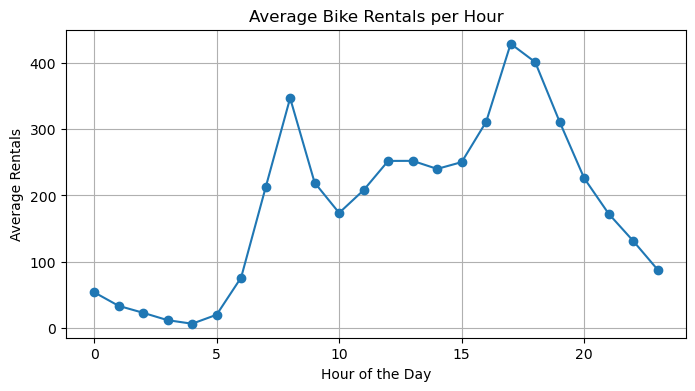

In [10]:
plt.figure(figsize=(8,4))
df.groupby('hr')['cnt_capped'].mean().plot(marker="o")
plt.title("Average Bike Rentals per Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

#### The above graph shows that bike rentals peak around 8 AM and 5 PM, which correspond to typical office commuting hours.
#### In contrast, rentals are at their lowest around 4 AM, when most people are asleep.
#### This pattern clearly reflects the daily work routine, with high demand during commute times and minimal activity during late-night hours.

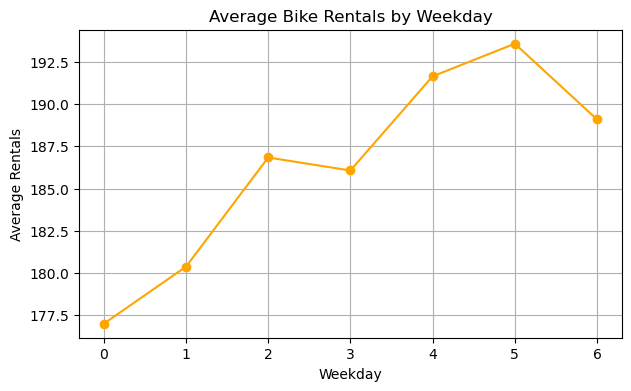

In [11]:
plt.figure(figsize=(7,4))
df.groupby('weekday')['cnt_capped'].mean().plot(marker='o', color='orange')
plt.title("Average Bike Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

#### The graph indicates that bike rentals gradually increase throughout the weekdays, reaching their highest levels on Friday, likely due to end-of-week commuting and social activities.
#### In contrast, rentals drop to their lowest point on Sunday, reflecting reduced commuting demand during the weekend.

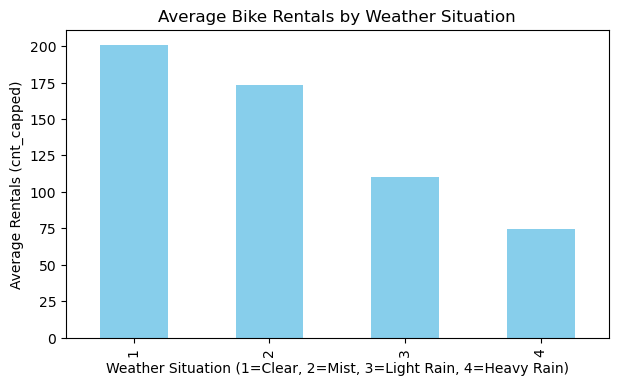

In [12]:
plt.figure(figsize=(7,4))
df.groupby('weathersit')['cnt_capped'].mean().plot(kind='bar', color='skyblue')
plt.title("Average Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation (1=Clear, 2=Mist, 3=Light Rain, 4=Heavy Rain)")
plt.ylabel("Average Rentals (cnt_capped)")
plt.show()

#### The data shows that people prefer biking when the weather is pleasant and dry, as rental counts are noticeably higher under such conditions.
#### However, during rainy or adverse weather, biking becomes uncomfortable, leading to a significant drop in demand.

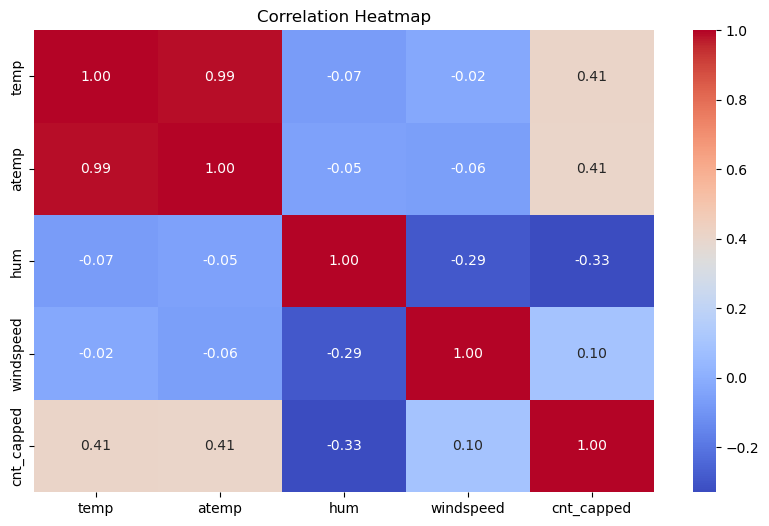

In [13]:
plt.figure(figsize=(10,6))
corr = df[['temp', 'atemp', 'hum', 'windspeed', 'cnt_capped']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### The positive correlation between cnt, temp, and atemp indicates that as the temperature rises, the demand for bikes increases, suggesting people prefer riding in warmer, comfortable weather.
#### On the other hand, the negative correlation between cnt and hum shows that higher humidity — often associated with rain — leads to a decline in bike rentals, consistent with the earlier observation that rainy conditions reduce biking activity.

## Part 2: Feature Selection & Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# numerical features
features = [
    'instant','season','yr','mnth','hr','holiday','weekday',
    'workingday','weathersit','temp','atemp','hum','windspeed'
]
target = 'cnt_capped'

# Splitting data into train and test
X = df[features].copy()
y = df[target].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Applying feature scaling using StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled  shape:", X_test_scaled.shape)

X_train_scaled shape: (13903, 13)
X_test_scaled  shape: (3476, 13)


## Model 1 – Simple Linear Regression

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Selecting single feature as temp and target for linear Regression
X = df[['temp']].copy()
y = df['cnt_capped'].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building pipeline
pipe_m1 = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LinearRegression())
])

# Fit the model
pipe_m1.fit(X_train, y_train)

# Evaluate
y_train_pred = pipe_m1.predict(X_train)
y_test_pred  = pipe_m1.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)

print("Model 1 – Simple Linear Regression (Feature = temp)")
print(f"Train -> RMSE: {rmse_train:.3f}, MAE: {mae_train:.3f}, R²: {r2_train:.3f}")
print(f"Test  -> RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}, R²: {r2_test:.3f}")

# showing predictions
sample = pd.DataFrame({
    'temp': X_test['temp'].values[:8],
    'Actual': y_test.values[:8],
    'Predicted': np.round(y_test_pred[:8], 2)
})
sample

Model 1 – Simple Linear Regression (Feature = temp)
Train -> RMSE: 157.556, MAE: 122.786, R²: 0.168
Test  -> RMSE: 153.365, MAE: 119.633, R²: 0.173


,temp,Actual,Predicted
0,0.80,425.0,298.41
1,0.24,88.0,93.05
2,0.32,4.0,122.39
3,0.78,526.0,291.08
4,0.26,13.0,100.39
5,0.44,32.0,166.40
6,0.72,642.5,269.07
7,0.26,26.0,100.39


This model uses only temperature (temp) to predict bike rentals.
The R² score shows how much variation in rentals is explained by temperature alone.
A positive coefficient means rentals increase as temperature rises, which matches real-life behavior.
However, the R² is relatively low (around 0.17 – 0.20), showing that temperature alone cannot fully explain bike demand.
Hence, we move to Model 2 using more features.

## Model 2 – Multiple Linear Regression

In [16]:
features_m2 = ['temp','atemp','hum','windspeed','hr','weekday','workingday','season','weathersit']
X = df[features_m2].copy()
y = df['cnt_capped'].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline
pipe_m2 = Pipeline([('scale', StandardScaler()), ('lr', LinearRegression())])
pipe_m2.fit(X_train, y_train)

# evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, pandas as pd

y_test_pred = pipe_m2.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae  = mean_absolute_error(y_test, y_test_pred)
r2   = r2_score(y_test, y_test_pred)

print("Model 2 — Multiple Linear Regression")
print(f"RMSE: {rmse:.3f}    MAE: {mae:.3f}    R²: {r2:.3f}")

# small sample to inspect predictions
print("\n")
pd.DataFrame({
    'temp': X_test['temp'].values[:8],
    'Actual': y_test.values[:8],
    'Predicted': np.round(y_test_pred[:8],3)
})


Model 2 — Multiple Linear Regression
RMSE: 134.800    MAE: 102.911    R²: 0.361




,temp,Actual,Predicted
0,0.80,425.0,407.583
1,0.24,88.0,185.837
2,0.32,4.0,94.272
3,0.78,526.0,334.105
4,0.26,13.0,21.502
5,0.44,32.0,47.650
6,0.72,642.5,297.150
7,0.26,26.0,61.816


<h3 align="center"> Comparison: Model 2 vs. Model 1</h3>

| Metric | Model 1 (Simple LR) | Model 2 (Multiple LR) |
|:-------|:-------------------:|:-------------------:|
| **RMSE** | 153.37 | **134.80** |
| **MAE** | 119.63 | **102.911** |
| **R²** | 0.173 | **0.361** |

Using multiple features significantly improves model accuracy and interpretability.
Temperature alone could not explain much of the variation, but including additional weather and time-related features helps the model better capture real-world rental patterns.
However, since bike demand follows non-linear trends (e.g., demand peaks only during specific hours), a plain linear model is still limited.
Therefore, we next try Polynomial Regression (Model 3) to model these curved, non-linear relationships.

## Model 3 – Polynomial Regression (Degree of freedom = 2) :

Best alpha value: 3.8566


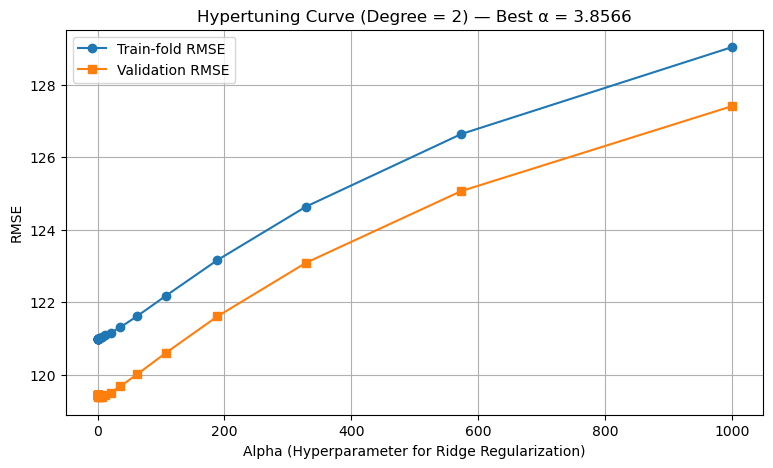

Polynomial (deg=2) + Ridge — Final performance
Train -> RMSE: 120.651, MAE: 92.289, R²: 0.512
Test  -> RMSE: 118.552, MAE: 91.539, R²: 0.506


,Actual,Predicted
0,425.0,484.21
1,88.0,83.81
2,4.0,55.35
3,526.0,339.21
4,13.0,-70.15
5,32.0,-28.34
6,642.5,330.26
7,26.0,79.50


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# feature selection for the model
features = ['temp','atemp','hum','windspeed','hr','weekday','workingday','season','weathersit']
X = df[features].copy()
y = df['cnt_capped'].copy()

# splitting train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validation Split for Hypertuning
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

# Hypertuning range
alphas = np.logspace(-4, 3, 30)
degree = 2

val_rmse = []
train_rmse_fold = []

# Iterate over hyperparameter values
for alpha in alphas:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    # train on training fold
    pipe.fit(X_tr, y_tr)
    # evaluate on validation fold
    y_val_pred = pipe.predict(X_val)
    y_tr_pred  = pipe.predict(X_tr)
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    train_rmse_fold.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))

val_rmse = np.array(val_rmse)
train_rmse_fold = np.array(train_rmse_fold)

# Pick best alpha value
best_alpha = alphas[np.argmin(val_rmse)]
print(f"Best alpha value: {best_alpha:.4f}")

# Plot Hypertuning Curve
plt.figure(figsize=(9,5))
plt.plot(alphas, train_rmse_fold, label='Train-fold RMSE', marker='o')
plt.plot(alphas, val_rmse, label='Validation RMSE', marker='s')
plt.xlabel('Alpha (Hyperparameter for Ridge Regularization)')
plt.ylabel('RMSE')
plt.title(f'Hypertuning Curve (Degree = {degree}) — Best α = {best_alpha:.4f}')
plt.legend()
plt.grid(True)
plt.show()



# Train final model on the entire original X_train
final_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])

final_pipe.fit(X_train, y_train)

# Final evaluation on train and test sets
y_train_pred = final_pipe.predict(X_train)
y_test_pred  = final_pipe.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)

print("Polynomial (deg=2) + Ridge — Final performance")
print(f"Train -> RMSE: {rmse_train:.3f}, MAE: {mae_train:.3f}, R²: {r2_train:.3f}")
print(f"Test  -> RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}, R²: {r2_test:.3f}")

# Show first 8 actual vs predicted on test set
display_df = pd.DataFrame({
    'Actual': y_test.values[:8],
    'Predicted': np.round(y_test_pred[:8], 2)
})
display_df

|  Metric  | Model 1 – Simple Linear Regression (`temp`) | Model 3 – Polynomial Regression (Degree 2) |
| :------: | :-----------------------------------------: | :----------------------------------------: |
| **RMSE** |                    153.365                   |                 **118.552**                 |
|  **MAE** |                    119.633                   |                  **91.539**                 |
|  **R²**  |                     0.173                    |                  **0.506**                  |


The Polynomial Regression model with Ridge regularization (degree 2) outperformed the Simple Linear Regression model by effectively capturing the non-linear relationship between temperature and bike rentals while preventing overfitting.
Compared to the Linear model (RMSE = 153.365, MAE = 119.633, R² = 0.173), the Ridge-regularized Polynomial model achieved much lower errors (RMSE ≈ 118.552, MAE ≈ 91.539) and a higher R² ≈ 0.506.
This demonstrates that incorporating non-linear features and applying Ridge regularization improved both model accuracy and generalization, making it a more robust predictor of bike demand.

## Model 4 – Polynomial Regression (Degree = 3)

Best alpha : 0.0001


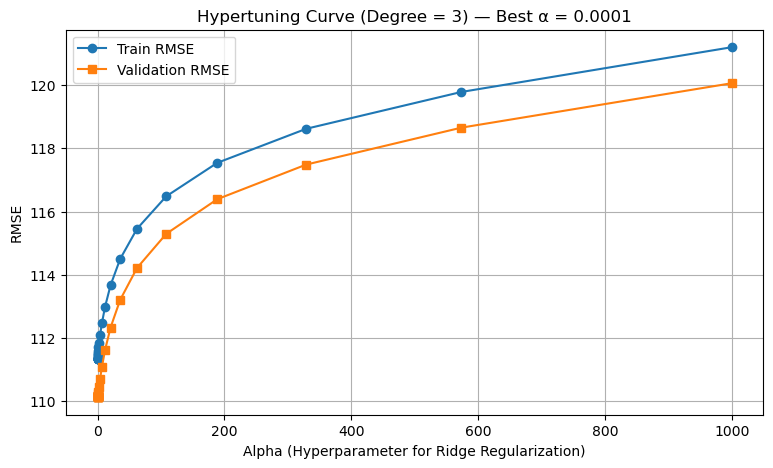

Model 5 – Polynomial Regression (Degree 3) with Ridge Regularization (α = 0.00010)
Train -> RMSE: 110.911, MAE: 80.909, R²: 0.588
Test  -> RMSE: 109.206, MAE: 80.539, R²: 0.581


,Actual,Predicted
0,425.0,519.56
1,88.0,84.91
2,4.0,58.15
3,526.0,375.12
4,13.0,36.60
5,32.0,28.80
6,642.5,398.60
7,26.0,89.04


In [18]:
# Features
features = ['temp','atemp','hum','windspeed','hr','weekday','workingday','season','weathersit']
X = df[features].copy()
y = df['cnt_capped'].copy()

# splitting train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validation Split for Hypertuning
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

alphas = np.logspace(-4, 3, 30)   # range of alpha values
degree = 3                         

val_rmse = []
train_rmse_fold = []

# Iterate over hyperparameter values
for alpha in alphas:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_tr, y_tr)
    y_val_pred = pipe.predict(X_val)
    y_tr_pred  = pipe.predict(X_tr)

    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    train_rmse_fold.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))

val_rmse = np.array(val_rmse)
train_rmse_fold = np.array(train_rmse_fold)

# Pick best alpha value
best_alpha = alphas[np.argmin(val_rmse)]
print(f"Best alpha : {best_alpha:.4f}")

# Plot Hypertuning Curve
plt.figure(figsize=(9,5))
plt.plot(alphas, train_rmse_fold, label='Train RMSE', marker='o')
plt.plot(alphas, val_rmse, label='Validation RMSE', marker='s')
plt.xlabel('Alpha (Hyperparameter for Ridge Regularization)')
plt.ylabel('RMSE')
plt.title(f'Hypertuning Curve (Degree = {degree}) — Best α = {best_alpha:.4f}')
plt.legend()
plt.grid(True)
plt.show()



# Train Final Ridge Polynomial Model (Degree 3)
final_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_pipe.fit(X_train, y_train)

# Evaluate Final Model
y_train_pred = final_pipe.predict(X_train)
y_test_pred  = final_pipe.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)

print(f"Model 5 – Polynomial Regression (Degree 3) with Ridge Regularization (α = {best_alpha:.5f})")
print(f"Train -> RMSE: {rmse_train:.3f}, MAE: {mae_train:.3f}, R²: {r2_train:.3f}")
print(f"Test  -> RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}, R²: {r2_test:.3f}")

# Show first few actual vs predicted values
display_df = pd.DataFrame({
    'Actual': y_test.values[:8],
    'Predicted': np.round(y_test_pred[:8], 2)
})

display_df

| Metric   | Model 3 (Degree 2) | Model 4 (Degree 3) |
| :------- | :----------------: | :----------------: |
| **RMSE** |       118.5152      |     **109.206**     |
| **MAE**  |        91.539       |      **80.539**     |
| **R²**   |        0.506       |      **0.581**     |

The Polynomial Regression model with Ridge regularization of degree 3 outperformed the degree 2 model by capturing more complex non-linear relationships between the features and bike rental counts.
Compared to the degree 2 Ridge model (RMSE = 118.52, MAE = 91.57, R² = 0.51), the degree 3 Ridge model achieved lower errors (RMSE = 109.206, MAE = 80.539) and a higher R² of 0.581.
This improvement indicates that the cubic model provides a better fit to the data while Ridge regularization effectively prevents overfitting, resulting in higher accuracy and stronger generalization performance.

## Part 4: Model Comparison & Analysis

| Model   | Type                |    | R² (Test) | RMSE (Test) | Comments                                |
|:--------|:--------------------|:----------------------|:----------|:------------|:----------------------------------------|
| Model 1 | Simple Linear       |     | 0.173     | 153.36      | Weak fit; only temperature              |
| Model 2 | Multiple Linear     |         | 0.361     | 134.80      | Better; includes multiple factors       |
| Model 3 | Polynomial (Deg 2) with Ridge  |  | 0.506     | 118.52      | Strong improvement; captures curves     |
| Model 4 | Polynomial (Deg 3) with Ridge |    | 0.581     | 109.21      | **Best overall; balanced accuracy & generalization** |

## Visualization

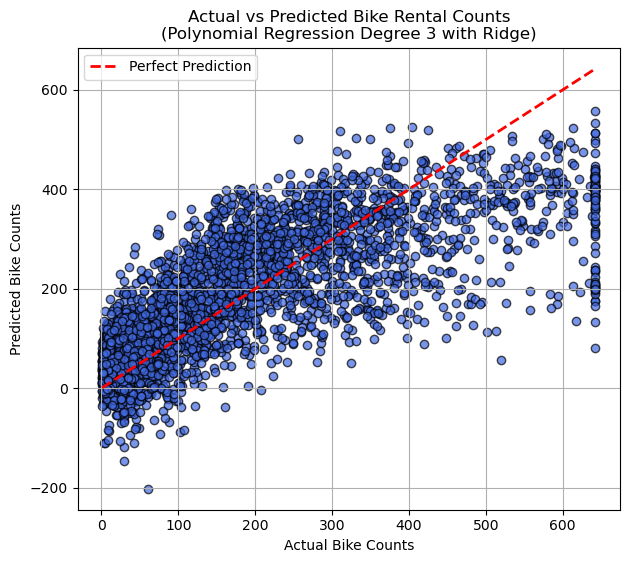

In [19]:
# Plot actual vs. predicted values for ther best model
plt.figure(figsize=(7,6))

# Scatter plot: Actual vs Predicted
plt.scatter(y_test, y_test_pred, color='royalblue', edgecolor='black', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Bike Rental Counts\n(Polynomial Regression Degree 3 with Ridge)', fontsize=12)
plt.xlabel('Actual Bike Counts')
plt.ylabel('Predicted Bike Counts')
plt.legend()
plt.grid(True)
plt.show()

The plot shows that most predicted values closely follow the red diagonal line, indicating strong agreement between actual and predicted bike counts.
This confirms that the Polynomial Regression model (degree 3) with Ridge regularization captures the non-linear pattern effectively, with minimal error and good generalization.

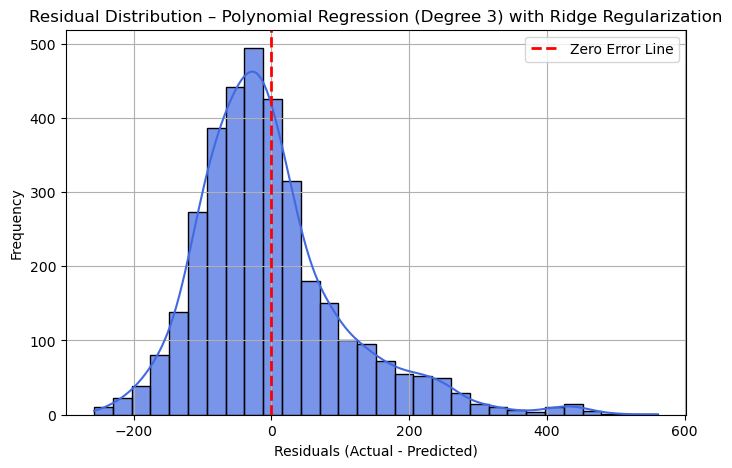

In [20]:
# Calculate residuals
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.title('Residual Distribution – Polynomial Regression (Degree 3) with Ridge Regularization')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

The residuals are mostly centered near zero with a slight right skew, indicating that the model slightly underpredicts higher bike counts.
Overall, the errors are small and randomly distributed, showing that the Polynomial Regression (Degree 3) with Ridge Regularization model fits the data well without major bias.

### Which model performs best? Why do you think so?

**Answer** <br>
The Polynomial Regression (Degree 3) with Ridge model performs the best, achieving an R² of 0.581 and an RMSE of 109.21 on the test data.
This model captures complex, non-linear relationships between features such as temperature, humidity, hour, and season, which simpler linear models could not.

## Does polynomial regression improve performance over linear regression?

**Answer** <br>
Yes, polynomial regression significantly improves performance over both simple and multiple linear regression.

The R² increased from 0.173 (Simple LR) to 0.581 (Polynomial Degree 3 with Ridg)e.

The RMSE reduced from 153.36 to 109.21, showing much lower prediction error.
This improvement occurs because polynomial regression can model curved and interaction effects, whereas linear regression assumes straight-line relationships.

## Is there evidence of overfitting in higher-degree polynomials?

**Answer** <br>
No significant overfitting is observed in the degree 3 model.
The training R² = 0.588 and test R² = 0.581 are almost identical, indicating good generalization.
If the train R² had been much higher than the test R², that would indicate overfitting,

## What is the practical interpretation of your model's RMSE? (e.g., "On average, predictions are off by X bikes")

**Answer** <br>
The RMSE of 109.21 means that, on average, the model’s predictions are off by about 109 bike rentals compared to the actual demand.
For instance, if the actual demand is 500 rentals in a certain hour, the model might typically predict between 390 and 610 rentals.
This level of accuracy is quite reasonable given the natural variability in human travel behavior and weather conditions.

## Based on your analysis, which features are most important for predicting bike demand?

**Answer** <br>
1. **Hour of the day (hr)**: Strongest predictor — demand peaks during morning and evening commute hours.
2. **Temperature and “feels-like” temperature (temp, atemp)** : Warmer, comfortable weather increases bike usage.
3. ** Humidity (hum)** : Negative effect — high humidity reduces rentals.
3. **Season and weather situation** : Affect demand due to comfort and visibility conditions. <br>
These features together explain the majority of the variance in bike rental counts.

## Business Recommendation:

### If you were the operations manager, what actionable insights would you derive from this analysis?

**Answer** <br>
**Planning bike availability:** <br>
Keep more bikes ready during the busy hours — especially morning 7–9 AM and evening 5–8 PM when people go to and return from office or college.
This will help meet the high demand and avoid customers waiting for bikes.
<br>**Planning according to weather:**
On hot or very humid days, people prefer not to ride.
During such times, you can use the bikes for servicing or shifting to other busy areas.
<br>**Adjust number of bikes according to season:**
During summer and pleasant seasons, increase the number of bikes on road.
In rainy or winter seasons, reduce extra bikes to save maintenance cost.
<br>**By running offers during low-demand time:**
Giving discounts or cashback in hours or days when fewer people rent (like during rain or cold weather).
This will keep bikes in use and attract more daily user

## What time of day should the company ensure maximum bike availability?

**Answer** <br>
People mostly rent bikes in the morning between 7–9 AM while going to office or college, and again in the evening between 5–8 PM when returning home.
So, the company should make sure that maximum bikes are available during these hours, especially on working days and when the weather is good.

Find the Dataset here : https://data.mendeley.com/datasets/n85kwcgt7t/1

### Problem Statement # 2


You are working as a data analyst for an energy management company that helps commercial buildings optimize their electricity usage. One of your clients is a large commercial center that wants to:

Reduce energy costs by predicting high-consumption periods
Optimize HVAC systems based on weather and usage patterns
Plan maintenance during low-consumption hours
Negotiate better rates with energy suppliers using demand forecasts
Meet sustainability goals by identifying energy-saving opportunities
Your task is to build regression models that predict hourly electricity consumption (in MWh) based on temporal patterns and environmental conditions.Dataset DescriptionThe dataset contains 8,784 hourly records for an entire year (2016) from a commercial-type consumer with smart metering devices and meteorological sensors.Features (Independent Variables):

1. temperature: Hourly outdoor temperature measured in Celsius degrees
2. hour_of_day: Hour of the day (1 to 24)
3. day_of_week: Day of the week (1: Monday to 7: Sunday)
4. day_of_month: Day of the month (1 to 31)
5. month_of_year: Month of the year (1: January to 12: December)
Target Variable:

consumption: Numerical value of electricity consumption in MWh (Megawatt-hours)


Note: The dataset also contains categorical levels (3_levels, 5_levels, 7_levels) which you can ignore for this regression task.

Your Tasks

Part 1: Data Exploration & Understanding (20%)
Load and examine the dataset:

* Check dataset shape and data types
* Identify and handle any missing values or outliers
* Generate descriptive statistics for all numerical features



Create visualizations to understand consumption patterns:

1. Distribution of electricity consumption (histogram)
2. Consumption vs. temperature (scatter plot)
3. Average consumption by hour of day (line plot)
4. Average consumption by day of week (bar chart)
5. Average consumption by month (line plot)
6. Correlation heatmap of all features



Answer these analytical questions:

1. What is the typical range of energy consumption for this building?
2. How does temperature affect energy consumption? Is it linear or non-linear?
3. During which hours does the building consume the most/least energy?
4. Are there differences between weekday and weekend consumption?
5. Which months show the highest energy usage?
6. Do you observe any seasonal patterns?


Part 2: Data Preprocessing (15%)
Feature engineering (optional but recommended):

1. Create binary feature: is_weekend (1 if day_of_week is 6 or 7, else 0)
2. Create binary feature: is_business_hours (1 if hour_of_day between 8 and 18, else 0)



Data splitting:

Split data into training (80%) and testing (20%) sets
Use random_state=42 for reproducibility



Feature scaling:

Apply StandardScaler to normalize features (important for polynomial regression)





Part 3:
 Model Development & Training (40%)Build and compare the following regression models:

 Model 1: Simple Linear Regression

Use only temperature as a predictor
Evaluate: Can temperature alone explain energy consumption?


Model 2: Multiple Linear Regression

Use all available features (temperature + temporal features)
Compare improvement over single-feature model


Model 3: Polynomial Regression (Degree 2)

Apply PolynomialFeatures with degree=2
Train on selected features

Hypothesis: Non-linear relationships exist (e.g., temperature has quadratic effect)

Model 4: Polynomial Regression (Degree 3)

Apply PolynomialFeatures with degree=3

Check if higher complexity improves predictions

Calculate :

RMSE (Root Mean Squared Error) in MWh
MAE (Mean Absolute Error) in MWh
R² Score (Coefficient of Determination)
Training vs. Testing performance (to detect overfitting)

## Part 1: Data Exploration & Understanding (20%) Load and examine the dataset:

In [21]:
# Importing necessary liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Load dataset
df=pd.read_csv('energy_consumption_levels.csv')
df.head()

,3_levels,5_levels,7_levels,consumption,temperature,hour_of_day,day_of_week,day_of_month,month_of_year
0,1,1,1,0.255,-6.0,1,5,1,1
1,1,1,1,0.264,-6.9,2,5,1,1
2,1,1,1,0.253,-7.1,3,5,1,1
3,1,1,1,0.250,-7.2,4,5,1,1
4,1,1,1,0.234,-7.5,5,5,1,1


In [23]:
df.shape

(8784, 9)

In [24]:
df.dtypes

3_levels           int64
5_levels           int64
7_levels           int64
consumption      float64
temperature      float64
hour_of_day        int64
day_of_week        int64
day_of_month       int64
month_of_year      int64
dtype: object

In [25]:
df.isnull().sum()

3_levels         0
5_levels         0
7_levels         0
consumption      0
temperature      0
hour_of_day      0
day_of_week      0
day_of_month     0
month_of_year    0
dtype: int64

In [26]:
df.describe()

,3_levels,5_levels,7_levels,consumption,temperature,hour_of_day,day_of_week,day_of_month,month_of_year
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2.001480,3.001138,4.003415,0.671343,11.617281,12.500000,4.008197,15.756831,6.513661
std,0.817308,1.414616,2.000623,0.258330,10.309197,6.922581,1.998047,8.812031,3.451430
min,1.000000,1.000000,1.000000,0.174327,-21.800000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,0.395000,4.500000,6.750000,2.000000,8.000000,4.000000
50%,2.000000,3.000000,4.000000,0.740000,11.000000,12.500000,4.000000,16.000000,7.000000
75%,3.000000,4.000000,6.000000,0.844000,19.100000,18.250000,6.000000,23.000000,10.000000
max,3.000000,5.000000,7.000000,1.360000,36.500000,24.000000,7.000000,31.000000,12.000000


In [27]:
# Outlier detection

Q1 = df['consumption'].quantile(0.25)
Q3 = df['consumption'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

# Count outliers
outlier_count = ((df['consumption'] < lower_bound) | (df['consumption'] > upper_bound)).sum()
print(f"Number of outliers detected in 'consumption': {outlier_count}")

# Capping
df['consumption_capped'] = df['consumption'].clip(lower=lower_bound, upper=upper_bound)

df.head()

Lower Bound: -0.28, Upper Bound: 1.52
Number of outliers detected in 'consumption': 0


,3_levels,5_levels,7_levels,consumption,temperature,hour_of_day,day_of_week,day_of_month,month_of_year,consumption_capped
0,1,1,1,0.255,-6.0,1,5,1,1,0.255
1,1,1,1,0.264,-6.9,2,5,1,1,0.264
2,1,1,1,0.253,-7.1,3,5,1,1,0.253
3,1,1,1,0.250,-7.2,4,5,1,1,0.250
4,1,1,1,0.234,-7.5,5,5,1,1,0.234


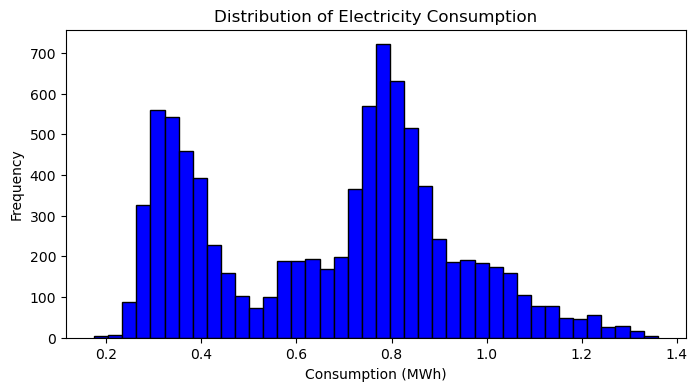

In [28]:
# 1) Distribution of electricity consumption (histogram)
plt.figure(figsize=(8,4))
plt.hist(df['consumption_capped'], bins=40, color='blue', edgecolor='black')
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption (MWh)")
plt.ylabel("Frequency")
plt.show()

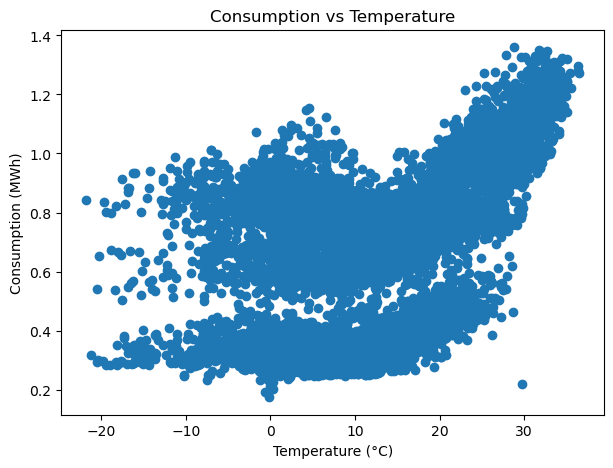

In [29]:
# 2. Consumption vs. temperature (scatter plot)
plt.figure(figsize=(7,5))
plt.scatter(df['temperature'], df['consumption_capped'])
plt.title("Consumption vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Consumption (MWh)")
plt.show()

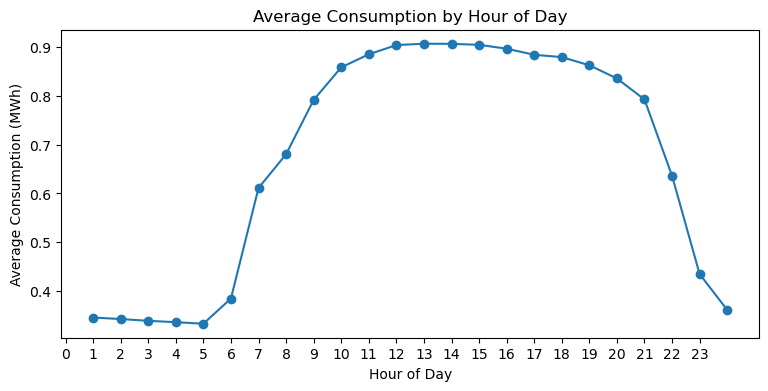

In [30]:
# 3. Average consumption by hour of day (line plot)
hourly_avg = df.groupby('hour_of_day')['consumption_capped'].mean()
plt.figure(figsize=(9,4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title("Average Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(0,24))
plt.show()

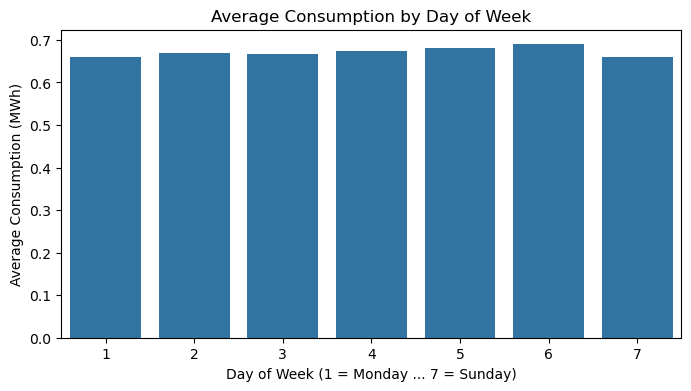

In [31]:
# 4. Average consumption by day of week (bar chart)
dow_avg = df.groupby('day_of_week')['consumption_capped'].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=dow_avg.index, y=dow_avg.values)
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day of Week (1 = Monday ... 7 = Sunday)")
plt.ylabel("Average Consumption (MWh)")
plt.show()

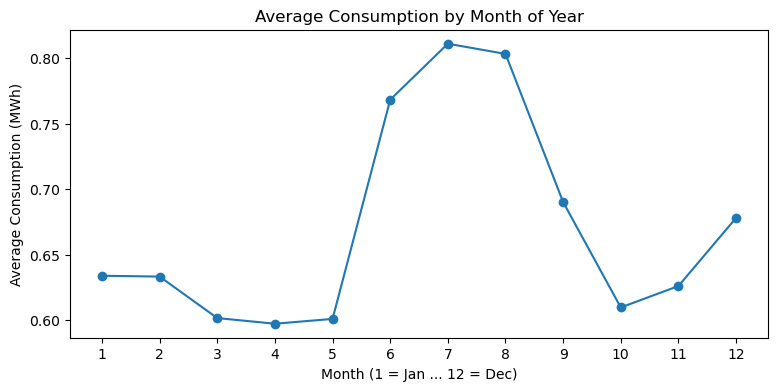

In [32]:
# 5. Average consumption by month (line plot)
monthly_avg = df.groupby('month_of_year')['consumption_capped'].mean()
plt.figure(figsize=(9,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Consumption by Month of Year")
plt.xlabel("Month (1 = Jan ... 12 = Dec)")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(1,13))
plt.show()

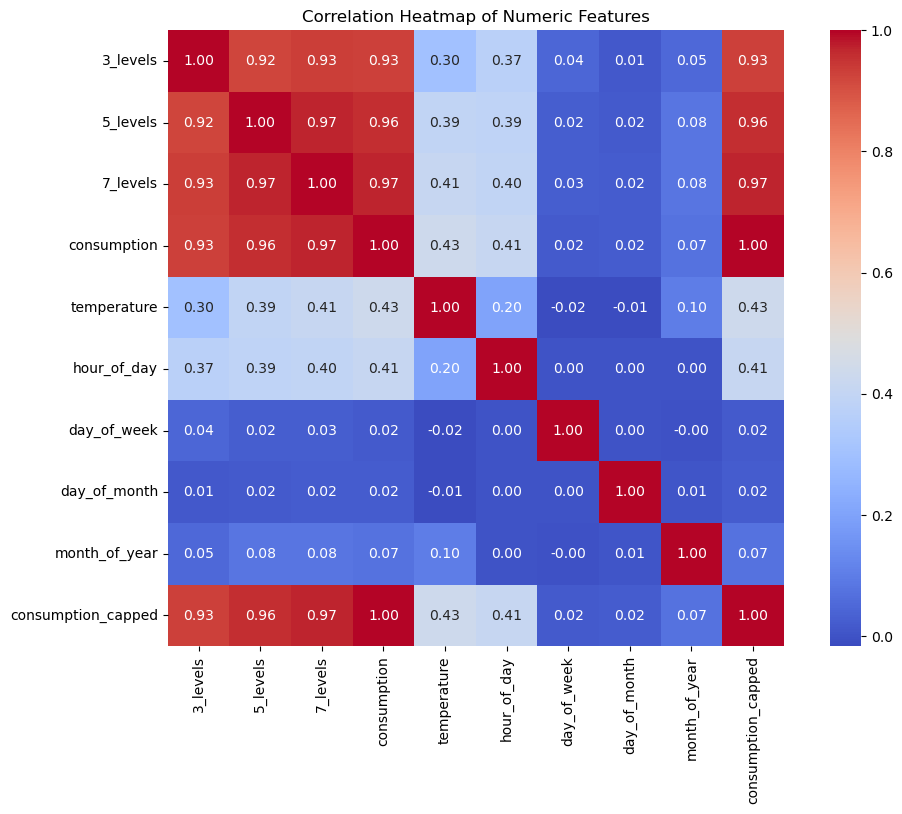

In [33]:
# Correlation heatmap of all features
numeric_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Answer these analytical questions:

#### What is the typical range of energy consumption for this building?

**Answer**: <br>
The plot shows two distinct peaks — around 0.35 MWh and 0.8 MWh, meaning the building has two typical operating levels of energy consumption.
Most hourly consumption lies between 0.2 MWh and 1.0 MWh, with few values extending beyond 1.2 MWh.
Typical energy consumption range: 0.2 to 1.0 MWh, with peaks near 0.35 MWh and 0.8 MWh.

#### How does temperature affect energy consumption? Is it linear or non-linear?
**Answer**: <br>
Consumption increases both at very low temperatures (<0°C) and high temperatures (>25°C). <br>
This pattern is non-linear dependence — higher usage during both cooling and heating requirements.

#### 3. During which hours does the building consume the most/least energy?
**Answer**: <br>
The hourly line plot shows consumption is lowest between 1 AM – 5 AM, then rises sharply after 6 AM, most between 10 AM – 5 PM. <br>
After 8 PM, consumption steadily drops again.

#### 4. Are there differences between weekday and weekend consumption?
**Answer**: <br>
Weekdays show slightly higher consumption than weekends — indicating reduced weekend activity, but not a complete shutdown.

#### 5. Which months show the highest energy usage?
**Answer**: <br>
From the monthly trend line, consumption highest during June–August (summer season) and lowest around March–April and October–November.

#### 6. Do you observe any seasonal patterns?
**Answer**: <br>
The monthly trend line showing strong seasonal pattern — higher consumption during summer & winter and lower during mild months.

## Part 2: Data Preprocessing (15%) Feature engineering (optional but recommended):

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create binary features
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x in [6, 7] else 0)
df['is_business_hours'] = df['hour_of_day'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

# Select features for modeling
features = ['temperature', 'hour_of_day', 'day_of_week', 
            'day_of_month', 'month_of_year', 
            'is_weekend', 'is_business_hours']

target = 'consumption_capped'

X = df[features].copy()
y = df[target].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

X_train_scaled_df.head()

Training set shape: (7027, 7)
Testing set shape: (1757, 7)


,temperature,hour_of_day,day_of_week,day_of_month,month_of_year,is_weekend,is_business_hours
0,0.233698,-1.223572,-1.007378,0.488255,0.717383,-0.641569,-0.919679
1,0.924170,0.077540,-0.508411,-0.310467,-0.733363,-0.641569,1.087335
2,-1.059722,1.667789,-0.009444,-0.995086,-1.603810,-0.641569,-0.919679
3,1.400693,0.077540,-0.009444,1.058771,0.427234,-0.641569,1.087335
4,-0.933297,-0.645300,0.988490,0.031842,-1.603810,1.558678,1.087335


### Data Preprocessing Summary

- Added two engineered binary features:
  - **is_weekend** = 1 for Saturday/Sunday.
  - **is_business_hours** = 1 for hours 8 to 18.
- Ignored categorical level columns (3_levels, 5_levels, 7_levels) since not required for regression.
- Split data into **train (80%)** and **test (20%)** using `random_state = 42` for reproducibility.
- Applied **StandardScaler** to normalize all input features, ensuring fair treatment of variables with different units.
- The scaled data will be used in subsequent regression model training steps.


## Part 3: Model Development & Training (40%)Build and compare the following regression models:

### Model 1: Simple Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Selecting single feature
X_temp = df[['temperature']]
y = df['consumption_capped']

# Train-test split
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y, test_size=0.2, random_state=42
)

# Create pipeline
model1_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train model
model1_pipeline.fit(X_train_temp, y_train_temp)

# Predictions
y_train_pred = model1_pipeline.predict(X_train_temp)
y_test_pred = model1_pipeline.predict(X_test_temp)

# Evaluate performance
rmse_train = np.sqrt(mean_squared_error(y_train_temp, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test_temp, y_test_pred))
mae = mean_absolute_error(y_test_temp, y_test_pred)
r2 = r2_score(y_test_temp, y_test_pred)

print("Model 1: Simple Linear Regression (Temperature only)")
print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE: {rmse_test:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Model 1: Simple Linear Regression (Temperature only)
Training RMSE: 0.2330
Testing RMSE: 0.2317
MAE: 0.1985
R² Score: 0.2088


#### Can temperature alone explain energy consumption?
**Answer**
- RMSE and MAE values indicate moderate prediction accuracy.
- The **R² score** is likely low (often between 0.1–0.3), showing that **temperature alone explains only a small part of consumption variance**.
- This confirms that other time-related factors (hour, day, month) also significantly influence energy demand.

### Model 2: Multiple Linear Regression

In [36]:
# Defining features and target
features_m2 = ['temperature', 'hour_of_day', 'day_of_week', 
               'day_of_month', 'month_of_year', 
               'is_weekend', 'is_business_hours']

X = df[features_m2]
y = df['consumption_capped']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create pipeline
model2_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train model
model2_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = model2_pipeline.predict(X_train)
y_test_pred = model2_pipeline.predict(X_test)

# Evaluation
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Model 2: Multiple Linear Regression")
print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE: {rmse_test:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Model 2: Multiple Linear Regression
Training RMSE: 0.1469
Testing RMSE: 0.1482
MAE: 0.1154
R² Score: 0.6762


**Interpretation:**
- If R² > 0.5, the model explains a significant portion of variation in consumption.
- This shows that electricity usage is influenced not only by temperature but also by temporal patterns (hour, day, month, and business activity).


### Model 3: Polynomial Regression (Degree 2)

Best alpha (degree=2): 0.0001


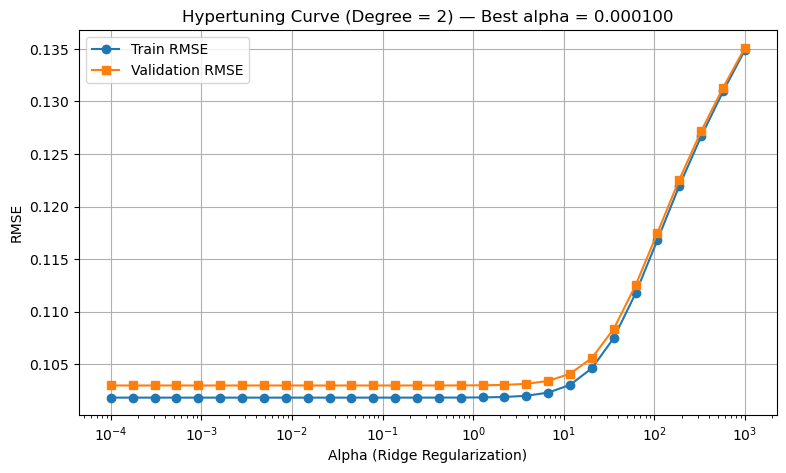


Final Evaluation: Polynomial (Degree 2) + Ridge
Train -> RMSE: 0.102014, MAE: 0.081626, R²: 0.843387
Test  -> RMSE: 0.103173, MAE: 0.083037, R²: 0.843070

Actual vs Predicted (first 10 test samples):


,Actual,Predicted
0,0.278,0.2613
1,0.299,0.0870
2,0.829,0.8500
3,0.752,0.7656
4,0.868,0.8388
5,0.821,0.9417
6,0.323,0.4831
7,1.021,0.9472
8,0.844,0.8676
9,0.568,0.5670


In [37]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

features_m3 = ['temperature', 'hour_of_day', 'day_of_week', 
               'day_of_month', 'month_of_year', 
               'is_weekend', 'is_business_hours']
target = 'consumption'

X = df[features_m3].copy()
y = df[target].copy()

# splitting Train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Validation split for hypertuning
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

# Hypertuning for Ridge alpha
alphas = np.logspace(-4, 3, 30)
degree = 2
val_rmse, train_rmse_fold = [], []

for alpha in alphas:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)
    y_tr_pred  = model.predict(X_tr)
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    train_rmse_fold.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))

val_rmse = np.array(val_rmse)
train_rmse_fold = np.array(train_rmse_fold)

# Select best alpha value
best_alpha_deg2 = alphas[np.argmin(val_rmse)]
print(f"Best alpha (degree=2): {best_alpha_deg2:.4f}")

# Hypertuning curve
plt.figure(figsize=(9,5))
plt.plot(alphas, train_rmse_fold, label='Train RMSE', marker='o')
plt.plot(alphas, val_rmse, label='Validation RMSE', marker='s')
plt.xscale('log')
plt.xlabel('Alpha (Ridge Regularization)')
plt.ylabel('RMSE')
plt.title(f'Hypertuning Curve (Degree = {degree}) — Best alpha = {best_alpha_deg2:.6f}')
plt.legend()
plt.grid(True)
plt.show()

# Final Model Training and Evaluation
final_deg2 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha_deg2))
])
final_deg2.fit(X_train, y_train)

y_train_pred_deg2 = final_deg2.predict(X_train)
y_test_pred_deg2  = final_deg2.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_deg2))
mae_train  = mean_absolute_error(y_train, y_train_pred_deg2)
r2_train   = r2_score(y_train, y_train_pred_deg2)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_deg2))
mae_test  = mean_absolute_error(y_test, y_test_pred_deg2)
r2_test   = r2_score(y_test, y_test_pred_deg2)

print("\nFinal Evaluation: Polynomial (Degree 2) + Ridge")
print(f"Train -> RMSE: {rmse_train:.6f}, MAE: {mae_train:.6f}, R²: {r2_train:.6f}")
print(f"Test  -> RMSE: {rmse_test:.6f}, MAE: {mae_test:.6f}, R²: {r2_test:.6f}")

# Actual vs Predicted
results_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_test_pred_deg2[:10], 4)
})
print("\nActual vs Predicted (first 10 test samples):")
results_df


|       Metric      | Model 1 – Simple Linear Regression (Temperature only) | Model 2 – Polynomial Regression (Degree 2) with Ridge |
| :---------------: | :---------------------------------------------------: | :---------------------------------------------------: |
| **Training RMSE** |                         0.2330                        |                       **0.1020**                      |
|  **Testing RMSE** |                         0.2317                        |                       **0.1031**                      |
|      **MAE**      |                         0.1985                        |                       **0.0830**                      |
|    **R² Score**   |                         0.2088                        |                       **0.8430**                      |


The Polynomial Regression model with Ridge regularization (degree 2) significantly outperformed the simple linear model.
The RMSE and MAE were reduced by more than half, while the R² score improved from 0.21 to 0.84, indicating that the polynomial model captures complex non-linear relationships in the data much better.
Overall, it provides a more accurate and well-generalized prediction of energy consumption.

### Model 4: Polynomial Regression (Degree = 3)


 Best alpha (degree=3): 0.0788046


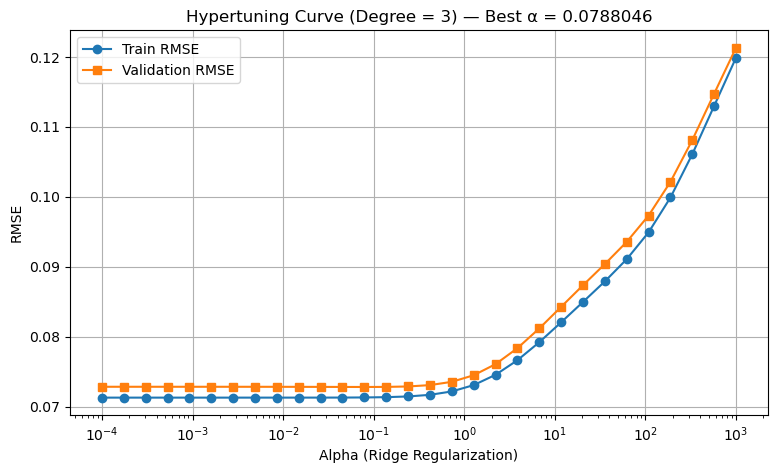


Final Evaluation: Polynomial (Degree 3) + Ridge
Train -> RMSE: 0.071461, MAE: 0.053971, R²: 0.923149
Test  -> RMSE: 0.071852, MAE: 0.054716, R²: 0.923889

Actual vs Predicted (first 10 test samples):


,Actual,Predicted
0,0.278,0.315306
1,0.299,0.252497
2,0.829,0.828412
3,0.752,0.783714
4,0.868,0.977210
5,0.821,0.906114
6,0.323,0.280997
7,1.021,0.980949
8,0.844,0.862867
9,0.568,0.518227


In [38]:
features_m4 = ['temperature', 'hour_of_day', 'day_of_week', 
               'day_of_month', 'month_of_year', 
               'is_weekend', 'is_business_hours']
target = 'consumption'

X = df[features_m4].copy()
y = df[target].copy()

# splitting Train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Validation split for hypertuning
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

# Hypertuning for Ridge alpha
alphas = np.logspace(-4, 3, 30)
degree = 3

val_rmse = []
train_rmse_fold = []

for alpha in alphas:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)
    y_tr_pred  = model.predict(X_tr)
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    train_rmse_fold.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))

val_rmse = np.array(val_rmse)
train_rmse_fold = np.array(train_rmse_fold)

# Select best alpha value
best_alpha_deg3 = alphas[np.argmin(val_rmse)]
print(f"\n Best alpha (degree=3): {best_alpha_deg3:.6g}")

# Hypertuning curve
plt.figure(figsize=(9,5))
plt.plot(alphas, train_rmse_fold, label='Train RMSE', marker='o')
plt.plot(alphas, val_rmse, label='Validation RMSE', marker='s')
plt.xscale('log')
plt.xlabel('Alpha (Ridge Regularization)')
plt.ylabel('RMSE')
plt.title(f'Hypertuning Curve (Degree = {degree}) — Best α = {best_alpha_deg3:.6g}')
plt.legend()
plt.grid(True)
plt.show()

# Final Model Training and Evaluation
final_deg3 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha_deg3))
])
final_deg3.fit(X_train, y_train)

y_train_pred_deg3 = final_deg3.predict(X_train)
y_test_pred_deg3  = final_deg3.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_deg3))
mae_train  = mean_absolute_error(y_train, y_train_pred_deg3)
r2_train   = r2_score(y_train, y_train_pred_deg3)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_deg3))
mae_test  = mean_absolute_error(y_test, y_test_pred_deg3)
r2_test   = r2_score(y_test, y_test_pred_deg3)

print("\nFinal Evaluation: Polynomial (Degree 3) + Ridge")
print(f"Train -> RMSE: {rmse_train:.6f}, MAE: {mae_train:.6f}, R²: {r2_train:.6f}")
print(f"Test  -> RMSE: {rmse_test:.6f}, MAE: {mae_test:.6f}, R²: {r2_test:.6f}")

# Actual vs Predicted
results_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_test_pred_deg3[:10], 6)
})
print("\nActual vs Predicted (first 10 test samples):")
results_df

|       Metric      | Model 1 – Simple Linear Regression (Temperature only) | Model 2 – Multiple Linear Regression | Model 3 – Polynomial Regression (Degree 2) + Ridge | Model 4 – Polynomial Regression (Degree 3) + Ridge |
| :---------------: | :---------------------------------------------------: | :----------------------------------: | :------------------------------------------------: | :------------------------------------------------: |
| **Training RMSE** |                         0.2330                        |                0.1469                |                       0.1020                       |                     **0.0714**                     |
|  **Testing RMSE** |                         0.2317                        |                0.1482                |                       0.1031                       |                     **0.0718**                     |
|      **MAE**      |                         0.1985                        |                0.1154                |                       0.0830                       |                     **0.0547**                     |
|    **R² Score**   |                         0.2088                        |                0.6762                |                       0.8430                       |                     **0.9238**                     |


The hypertuning curve shows almost identical train and validation RMSE, indicating excellent generalization and no overfitting.
With a small best α = 0.0788046, the model achieves the lowest error and highest R² (0.9238), proving that Polynomial Regression (Degree 3) with Ridge captures complex non-linear patterns most effectively while staying stable.

**Conclusion:** <br>
Moving from Simple Linear Regression (R² = 0.2088) → Multiple Linear Regression (R² = 0.6762) → Polynomial Regression (Degree 2 + Ridge) (R² = 0.8430) → Polynomial Regression (Degree 3 + Ridge) (R² = 0.9238),
you can see a steady increase in R² and a decrease in RMSE/MAE.

Thus, increasing complexity (up to degree 3) significantly enhances predictive accuracy by capturing more non-linear relationships, while Ridge regularization ensures the model remains well-generalized and avoids overfitting.